# Competition 1: Beer Quality Prediction 🍺

This notebook provides starter code for the Beer Quality Prediction competition. For full instructions, problem statement, and grading criteria, please refer to the **README.md** file.

**Quick Summary**: You will build a classification model to predict beer quality (scores 1-10) based on chemical properties. Submit your predictions to [Kaggle](https://www.kaggle.com/competitions/ift-6390-ift-3395-beer-quality-prediction/).

## Import Dependencies

In [58]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Explore Data

In [59]:
# Load the training data
train_df = pd.read_csv('data/train.csv', delimiter=';', index_col="id")

# Training Data 
print(f"Training data shape: {train_df.shape}")
print(f"Number of samples (n): {train_df.shape[0]}")
print(f"Number of features (d): {train_df.shape[1] - 1}")  # Subtract 1 for target column
print(f"Columns: {list(train_df.columns)}")
print("\nFirst few rows:")
print(train_df.head())


Training data shape: (4469, 14)
Number of samples (n): 4469
Number of features (d): 13
Columns: ['beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength', 'quality']

First few rows:
   beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
id                                                                   
0        Pale           7.997                   0.446        0.280   
1        Pale           6.906                   0.222        0.303   
2       Brown           7.183                   0.636        0.071   
3        Pale           6.403                   0.242        0.260   
4       Brown           7.917                   0.182        0.347   

    final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity  \
id                                                                        
0          10.803   

In [60]:
# Check data types and basic info
print("\nData types and info for train df:")
print(train_df.info())


Data types and info for train df:
<class 'pandas.core.frame.DataFrame'>
Index: 4469 entries, 0 to 4468
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   beer_style              4469 non-null   object 
 1   bitterness_IBU          4469 non-null   float64
 2   diacetyl_concentration  4469 non-null   float64
 3   lactic_acid             4469 non-null   float64
 4   final_gravity           4469 non-null   float64
 5   sodium                  4469 non-null   float64
 6   free_CO2                4469 non-null   float64
 7   dissolved_oxygen        4469 non-null   float64
 8   original_gravity        4469 non-null   float64
 9   pH                      4469 non-null   float64
 10  gypsum_level            4469 non-null   float64
 11  alcohol_ABV             4469 non-null   float64
 12  fermentation_strength   4469 non-null   float64
 13  quality                 4469 non-null   int64  
dtypes: float64

In [61]:
test_df = pd.read_csv('data/test.csv', delimiter=';', index_col="id")

# Test Data 
print(f"Test data shape: {test_df.shape}")
print(f"Number of samples (n): {test_df.shape[0]}")
print(f"Columns: {list(test_df.columns)}")
print("\nFirst few rows:")
print(test_df.head())

Test data shape: (511, 13)
Number of samples (n): 511
Columns: ['beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength']

First few rows:
   beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
id                                                                   
0      Golden           7.904                   0.419        0.501   
1        Pale           6.317                   0.223        0.575   
2      Golden           5.483                   0.347        0.254   
3        Pale           5.183                   0.515        0.166   
4        Dark          13.505                   0.527        0.792   

    final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity  \
id                                                                        
0           8.200   0.074    31.994           163.998           

In [62]:
# Check data types and basic info
print("\nData types and info for test df:")
print(test_df.info())


Data types and info for test df:
<class 'pandas.core.frame.DataFrame'>
Index: 511 entries, 0 to 510
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   beer_style              511 non-null    object 
 1   bitterness_IBU          511 non-null    float64
 2   diacetyl_concentration  511 non-null    float64
 3   lactic_acid             511 non-null    float64
 4   final_gravity           511 non-null    float64
 5   sodium                  511 non-null    float64
 6   free_CO2                511 non-null    float64
 7   dissolved_oxygen        511 non-null    float64
 8   original_gravity        511 non-null    float64
 9   pH                      511 non-null    float64
 10  gypsum_level            511 non-null    float64
 11  alcohol_ABV             511 non-null    float64
 12  fermentation_strength   511 non-null    float64
dtypes: float64(12), object(1)
memory usage: 55.9+ KB
None


In [63]:
## Data Exploration and Visualization Continued 
# Listing column names for train and test data 

# Printing summary statistics 
print("\n Summary Statistics")
display(train_df.describe())

# Data Type per feature 
print("\n Data Type per feature")
print(train_df.dtypes.value_counts)



 Summary Statistics


,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
count,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000
mean,7.235609,0.338640,0.317996,5.506593,0.055572,30.744267,116.383056,0.994855,3.217238,0.528450,4.986386,9.478692,5.811815
std,1.296424,0.163701,0.145221,4.741626,0.033916,18.011711,56.441889,0.010509,0.161431,0.143315,0.560061,0.892119,0.838949
min,3.804000,0.064000,-0.022000,0.596000,-0.004000,0.998000,5.991000,0.957000,2.723000,0.216000,3.816000,7.429000,3.000000
25%,6.410000,0.226000,0.245000,1.805000,0.037000,16.999000,78.994000,0.988000,3.107000,0.430000,4.524000,8.778000,5.000000
50%,6.996000,0.293000,0.308000,3.119000,0.049000,29.001000,118.997000,0.995000,3.205000,0.506000,4.904000,9.348000,6.000000
75%,7.697000,0.404000,0.393000,8.196000,0.067000,41.984000,156.000000,1.002000,3.320000,0.598000,5.382000,10.109000,6.000000
max,15.885000,1.572000,1.672000,31.612000,0.603000,288.995000,440.004000,1.032000,4.006000,1.989000,7.096000,12.648000,9.000000



 Data Type per feature
<bound method IndexOpsMixin.value_counts of beer_style                 object
bitterness_IBU            float64
diacetyl_concentration    float64
lactic_acid               float64
final_gravity             float64
sodium                    float64
free_CO2                  float64
dissolved_oxygen          float64
original_gravity          float64
pH                        float64
gypsum_level              float64
alcohol_ABV               float64
fermentation_strength     float64
quality                     int64
dtype: object>


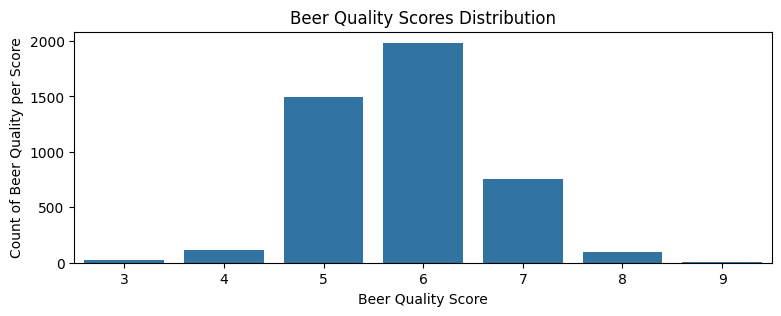

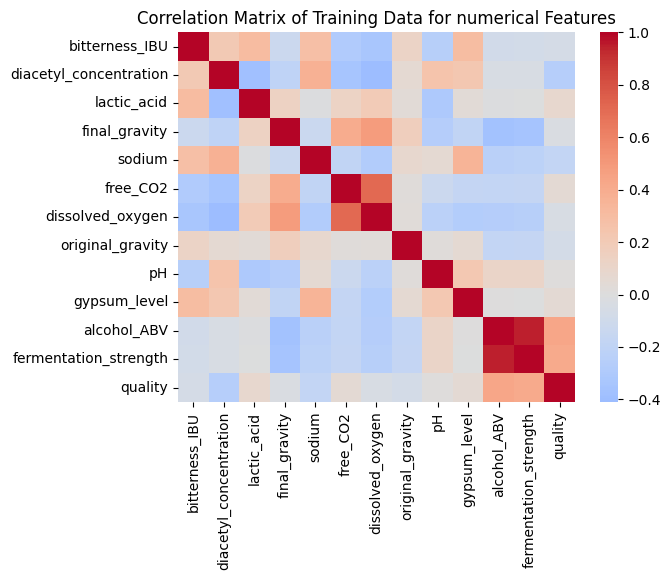

In [64]:
## Data Visualization and Exploring
## Visualizing Target variables
plt.figure(figsize=(9,3))
sns.countplot(x="quality",data=train_df)
plt.title("Beer Quality Scores Distribution")
plt.xlabel("Beer Quality Score")
plt.ylabel("Count of Beer Quality per Score")
plt.show()

## Plotting Correlation Matrix for numerical Features 
features = train_df.select_dtypes(include=["float64", "int64"]).columns
sns.heatmap(train_df[features].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Training Data for numerical Features")
plt.show()

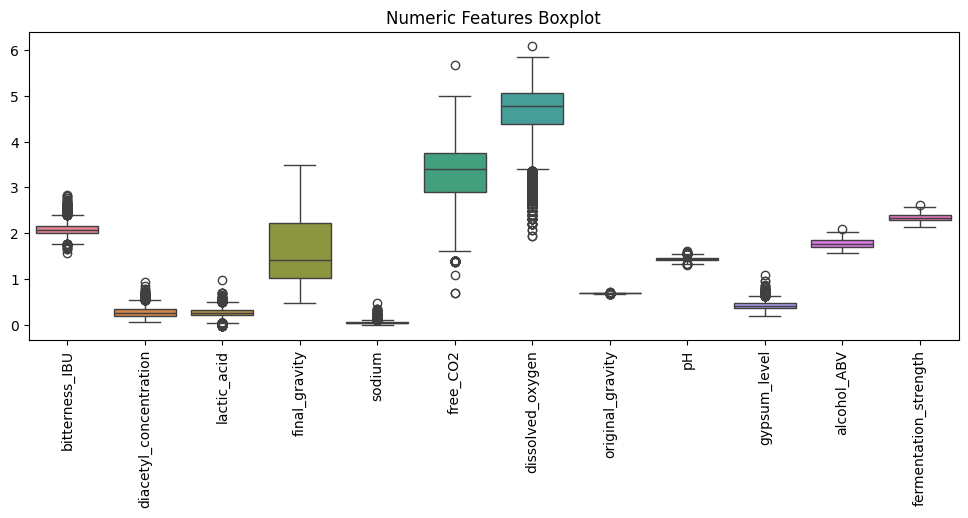

In [65]:
## Detecting Outliers for feature columns 
plt.figure(figsize=(12,4))
sns.boxplot(data=np.log1p(train_df[features.drop(["quality"], errors='ignore')]))
plt.xticks(rotation=90)
plt.title("Numeric Features Boxplot")
plt.show()

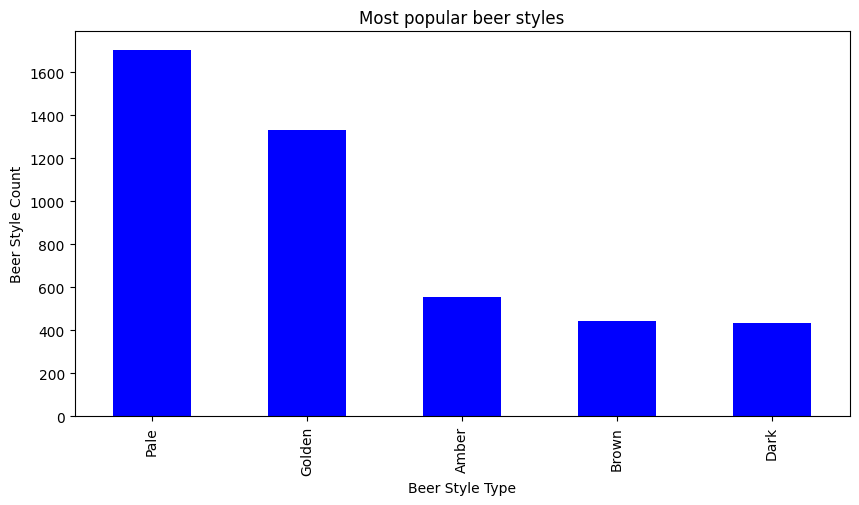

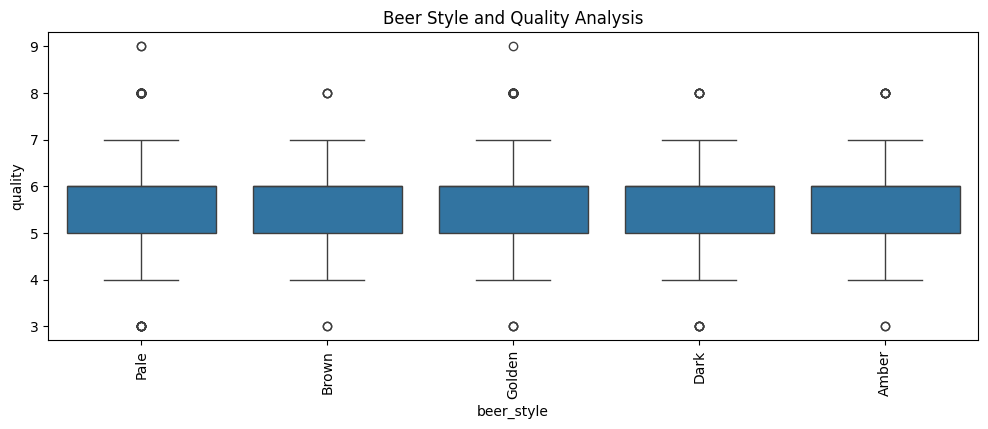

In [66]:
## Analyzing Categorial feature - Beer Style column 
plt.figure(figsize=(10,5))
train_df["beer_style"].value_counts().head().plot(kind="bar", color="blue")
plt.title("Most popular beer styles")
plt.xlabel("Beer Style Type")
plt.ylabel("Beer Style Count")
plt.show()

## Analyzing Beer Stlye relationship with Target 
plt.figure(figsize=(12,4))
sns.boxplot(x="beer_style", y="quality", data=train_df)
plt.xticks(rotation=90)
plt.title("Beer Style and Quality Analysis")
plt.show()

## Data Preprocessing

Implement your preprocessing pipeline (see README.md for suggestions).

In [67]:
# First copy the data frames to avoid modifying the original data frames
df_train = train_df.copy()
df_test = test_df.copy()

# Investigate missing values
print("Investigating the missing values before imputation.")
print(train_df.isnull().sum().sort_values(ascending=False))

# Fill numeric columns
# Identify numeric columns (exclude 'quality' if present)
numeric_cols = [col for col in df_train.select_dtypes(include=["float64", "int64"]).columns if col != "quality"]

for col in numeric_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())
    df_test[col] = df_test[col].fillna(df_train[col].median())

# Fill categorical column
df_train["beer_style"] = df_train["beer_style"].fillna(df_train["beer_style"].mode()[0])
df_test["beer_style"] = df_test["beer_style"].fillna(df_train["beer_style"].mode()[0])

# Print results
print("\n Missing values after imputations for Training data:")
print(df_train.isnull().sum().sum())

print("\n Missing values after imputations for Testing data:")
print(df_test.isnull().sum().sum())











Investigating the missing values before imputation.
beer_style                0
bitterness_IBU            0
diacetyl_concentration    0
lactic_acid               0
final_gravity             0
sodium                    0
free_CO2                  0
dissolved_oxygen          0
original_gravity          0
pH                        0
gypsum_level              0
alcohol_ABV               0
fermentation_strength     0
quality                   0
dtype: int64

 Missing values after imputations for Training data:
0

 Missing values after imputations for Testing data:
0


In [68]:
## Correlation:
## Printing the Top Correlated Features with quality 
correlation = df_train.drop(columns=["beer_style"]).corr()["quality"].sort_values(ascending=False)
print("\nTop Correlated Featurs: ")
print(correlation.head(15))

# Seeing relationship between quality and beer style
quality_bstyle = df_train.groupby('beer_style')['quality'].mean().sort_values(ascending=False)
print(quality_bstyle)


Top Correlated Featurs: 
quality                   1.000000
alcohol_ABV               0.431341
fermentation_strength     0.413183
lactic_acid               0.084787
gypsum_level              0.050557
free_CO2                  0.048471
pH                        0.010023
final_gravity            -0.025243
dissolved_oxygen         -0.043244
bitterness_IBU           -0.066856
original_gravity         -0.070534
sodium                   -0.181036
diacetyl_concentration   -0.258663
Name: quality, dtype: float64
beer_style
Golden    5.889474
Amber     5.854578
Pale      5.839789
Brown     5.631222
Dark      5.594037
Name: quality, dtype: float64


In [69]:
# Seeing relationship between alcohol ABV and Fermentation Strength 
df_train[["alcohol_ABV", "fermentation_strength"]].corr()


,alcohol_ABV,fermentation_strength
alcohol_ABV,1.000000,0.947515
fermentation_strength,0.947515,1.000000


In [70]:
# Seeing relationship between bitterness IBU and original gravity
df_train[["bitterness_IBU", "original_gravity"]].corr()

,bitterness_IBU,original_gravity
bitterness_IBU,1.000000,0.122553
original_gravity,0.122553,1.000000


In [71]:
# Seeing relationship between lactic acid, gypsum levels, and free CO2
df_train[["lactic_acid", "gypsum_level", "free_CO2"]].corr()

,lactic_acid,gypsum_level,free_CO2
lactic_acid,1.000000,0.035633,0.133657
gypsum_level,0.035633,1.000000,-0.175459
free_CO2,0.133657,-0.175459,1.000000


In [72]:
# Dropping Fermentation strength 
#df_train = df_train.drop(columns=['fermentation_strength'])
#df_test = df_test.drop(columns=['fermentation_strength'])

In [73]:
## Encoding the Beer Style Column 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Defining numeric columns 
numeric_cols = df_train.select_dtypes(include=['float64', 'int64']).columns.drop('quality',errors='ignore')

# Defining categorical columns 
categorical_cols = ["beer_style"]

# Define preprocessor for OneHotEncoding and use Standard Scaler for normalized data 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# Defining X as feature columns 
X = df_train.drop(columns=['quality'])
# Y as target label column
y = df_train['quality']

# Encoding X with Preprocesors 
X_encoded = preprocessor.fit_transform(X)

print("X_encoded_shape: ", X_encoded.shape)

ohe = preprocessor.named_transformers_['cat']
encoded_cols = ohe.get_feature_names_out(categorical_cols)
all_features = list(numeric_cols) + list(encoded_cols)
print("Final feature names:", all_features)


X_encoded_shape:  (4469, 16)
Final feature names: ['bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength', 'beer_style_Brown', 'beer_style_Dark', 'beer_style_Golden', 'beer_style_Pale']


In [74]:
## Final Analysis of Results after preprocessing 
print("\nTraining data shape")
print(X_encoded.shape)
print("\nTraining data types")
print(type(X_encoded))
print("\nTest data shape")
print(df_test.shape)


Training data shape
(4469, 16)

Training data types
<class 'numpy.ndarray'>

Test data shape
(511, 13)


## Prepare Training and Validation Data

Split your data into training and validation sets.

In [76]:
## Splitting Data into Train and Test Validation Sets: 
from sklearn.model_selection import train_test_split
# Defining training and validation data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##Printing Training and Training and Validation Set Sizes: 
print(f"Training set sizes for X_train (features) are: {X_train.shape[0]}, Training set sizes for y_train (labels): {y_train.shape}")
print(f"Validation set sizes for X_val (features) are:   {X_val.shape[0]}, Training set sizes for y_val (labels):   {y_val.shape}")


Training set sizes for X_train (features) are: 3575, Training set sizes for y_train (labels): (3575,)
Validation set sizes for X_val (features) are:   894, Training set sizes for y_val (labels):   (894,)


In [77]:
y_train.value_counts(normalize=True).sort_index()


quality
3    0.004755
4    0.026014
5    0.334825
6    0.444196
7    0.168951
8    0.020699
9    0.000559
Name: proportion, dtype: float64

✅ Encoded shapes — X_train: (3575, 22), X_val: (894, 22)
🔹 Training KNN(k=2, weights=uniform, p=1)...
✅ k=2, w=uniform, p=1 → Accuracy=0.539, F1=0.521
🔹 Training KNN(k=6, weights=uniform, p=1)...
✅ k=6, w=uniform, p=1 → Accuracy=0.538, F1=0.516
🔹 Training KNN(k=10, weights=uniform, p=1)...
✅ k=10, w=uniform, p=1 → Accuracy=0.540, F1=0.520
🔹 Training KNN(k=14, weights=uniform, p=1)...
✅ k=14, w=uniform, p=1 → Accuracy=0.557, F1=0.534
🔹 Training KNN(k=18, weights=uniform, p=1)...
✅ k=18, w=uniform, p=1 → Accuracy=0.565, F1=0.540
🔹 Training KNN(k=22, weights=uniform, p=1)...
✅ k=22, w=uniform, p=1 → Accuracy=0.538, F1=0.514
🔹 Training KNN(k=26, weights=uniform, p=1)...
✅ k=26, w=uniform, p=1 → Accuracy=0.547, F1=0.520
🔹 Training KNN(k=30, weights=uniform, p=1)...
✅ k=30, w=uniform, p=1 → Accuracy=0.549, F1=0.523
🔹 Training KNN(k=34, weights=uniform, p=1)...
✅ k=34, w=uniform, p=1 → Accuracy=0.553, F1=0.524
🔹 Training KNN(k=38, weights=uniform, p=1)...
✅ k=38, w=uniform, p=1 → Accuracy=0.5

,k,weights,p,Accuracy,Precision,Recall,F1-Score
27,30,distance,1,0.570470,0.537991,0.570470,0.546690
29,38,distance,1,0.567114,0.535468,0.567114,0.542507
28,34,distance,1,0.565996,0.532881,0.565996,0.541817
4,18,uniform,1,0.564877,0.528348,0.564877,0.539979
24,18,distance,1,0.563758,0.530908,0.563758,0.542662
23,14,distance,1,0.560403,0.528355,0.560403,0.540157
38,34,distance,2,0.559284,0.525379,0.559284,0.532925
19,38,uniform,2,0.558166,0.520204,0.558166,0.526479
36,26,distance,2,0.557047,0.527386,0.557047,0.533932
26,26,distance,1,0.557047,0.524642,0.557047,0.533198


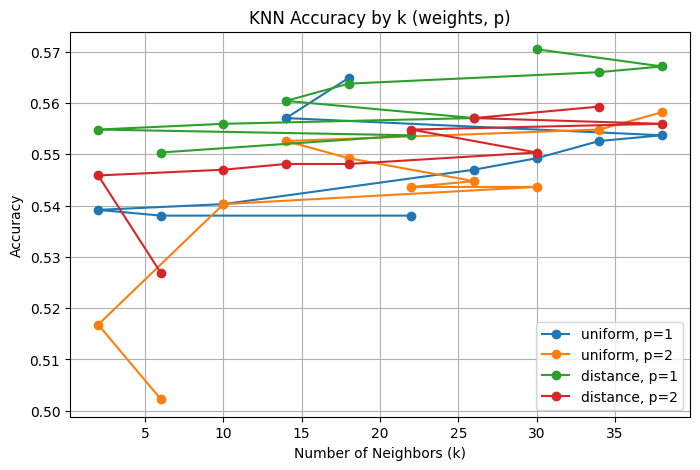


🏆 Best KNN Configuration:
k                  30
weights      distance
p                   1
Accuracy      0.57047
Precision    0.537991
Recall        0.57047
F1-Score      0.54669
Name: 27, dtype: object
✅ Best KNN model retrained on training data.


In [111]:
## Evaluating KNN Models
# ===============================================================
# ⚡ Lucius KNN Optimization v6.2 — Focused Performance Sweep
# ===============================================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================================================
# 🔹 Reapply preprocessing (in case of prior pipeline edits)
# ===============================================================
X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)

print(f"✅ Encoded shapes — X_train: {X_train_encoded.shape}, X_val: {X_val_encoded.shape}")

# ===============================================================
# 🔹 Define range of K and hyperparameters
# ===============================================================
k_values = list(range(2, 40, 4))  # [2, 6, 10, 14, 18, 22, 26, 30]
weights_options = ['uniform', 'distance']
p_options = [1, 2]  # Manhattan, Euclidean

results = []

# ===============================================================
# 🔹 Model Evaluation Loop
# ===============================================================
for w in weights_options:
    for p in p_options:
        for k in k_values:
            print(f"🔹 Training KNN(k={k}, weights={w}, p={p})...")
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(
                    n_neighbors=k,
                    weights=w,
                    p=p,
                    leaf_size=20,
                    n_jobs=-1
                ))
            ])
            model.fit(X_train_encoded, y_train)
            y_pred = model.predict(X_val_encoded)

            acc = accuracy_score(y_val, y_pred)
            prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
            rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

            results.append({
                "k": k,
                "weights": w,
                "p": p,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1-Score": f1
            })
            print(f"✅ k={k}, w={w}, p={p} → Accuracy={acc:.3f}, F1={f1:.3f}")

# ===============================================================
# 🔹 Summarize and Plot Results
# ===============================================================
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n📊 Top 10 KNN Configurations by Accuracy:")
display(results_df.head(10))

# Plot accuracy trend for easier visualization
plt.figure(figsize=(8,5))
for w in weights_options:
    for p in p_options:
        subset = results_df[(results_df['weights']==w) & (results_df['p']==p)]
        plt.plot(subset['k'], subset['Accuracy'], marker='o', label=f"{w}, p={p}")

plt.title("KNN Accuracy by k (weights, p)")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ===============================================================
# 🔹 Save Best Model for Later Use
# ===============================================================
best_params = results_df.iloc[0]
print(f"\n🏆 Best KNN Configuration:")
print(best_params)

best_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=int(best_params['k']),
        weights=best_params['weights'],
        p=int(best_params['p']),
        leaf_size=20,
        n_jobs=-1
    ))
])
best_knn.fit(X_train_encoded, y_train)
print("✅ Best KNN model retrained on training data.")


✅ Engineered features added successfully!
New training columns: ['beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength', 'quality', 'abv_to_ibu', 'acid_to_gravity', 'abv_times_acid', 'sodium_squared', 'log_final_gravity', 'log_dissolved_oxygen']

🚀 Starting Model Training with Engineered Features...

✅ Random Forest: Accuracy=0.609, F1=0.579
✅ KNN (k=10, dist): Accuracy=0.575, F1=0.556


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.608501,0.575649,0.608501,0.578586
1,"KNN (k=10, dist)",0.574944,0.543318,0.574944,0.556226



🏆 Best model after feature engineering: Random Forest


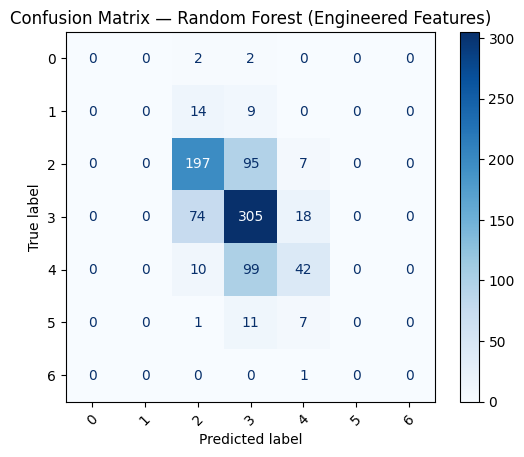

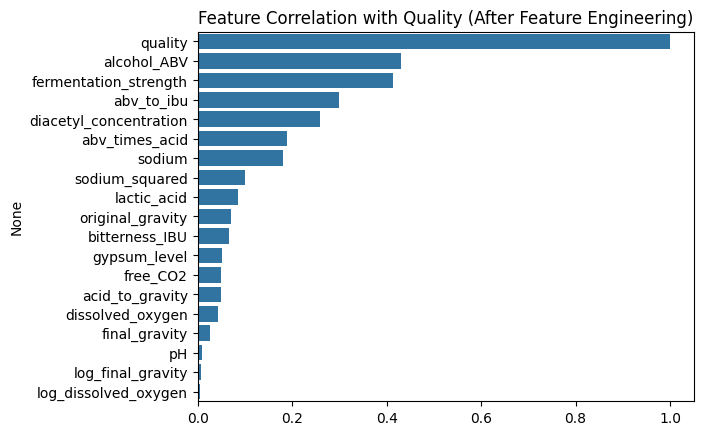

In [100]:
# ===============================================================
# ⚡ Lucius Code V10 — Feature Engineering + Model Re-Evaluation
# ===============================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================================================
# 🔹 Step 1 — Create New Engineered Features
# ===============================================================
def add_engineered_features(df):
    df = df.copy()

    # Ratios & Interactions
    df["abv_to_ibu"] = df["alcohol_ABV"] / (df["bitterness_IBU"] + 1e-5)
    df["acid_to_gravity"] = df["lactic_acid"] / (df["final_gravity"] + 1e-5)
    df["abv_times_acid"] = df["alcohol_ABV"] * df["lactic_acid"]

    # Nonlinear transforms
    df["sodium_squared"] = df["sodium"] ** 2
    df["log_final_gravity"] = np.log1p(df["final_gravity"])
    df["log_dissolved_oxygen"] = np.log1p(df["dissolved_oxygen"])

    return df

# Apply to both training and test data
df_train_fe = add_engineered_features(df_train)
df_test_fe = add_engineered_features(df_test)

print("✅ Engineered features added successfully!")
print("New training columns:", df_train_fe.columns.tolist())

# ===============================================================
# 🔹 Step 2 — Update Preprocessing (OneHot + Scaling)
# ===============================================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_cols = df_train_fe.select_dtypes(include=["float64", "int64"]).columns.drop("quality", errors="ignore")
categorical_cols = ["beer_style"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)

# ===============================================================
# 🔹 Step 3 — Split Train/Validation Sets
# ===============================================================
X = df_train_fe.drop(columns=["quality"])
y = df_train_fe["quality"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ===============================================================
# 🔹 Step 4 — Train Two Top Models: RandomForest & KNN
# ===============================================================
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "KNN (k=10, dist)": KNeighborsClassifier(n_neighbors=10, weights="distance", p=1, n_jobs=-1)
}

results = []
print("\n🚀 Starting Model Training with Engineered Features...\n")

for name, model in models.items():
    from sklearn.pipeline import Pipeline
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_val, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_val, y_pred, average="weighted", zero_division=0)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})
    print(f"✅ {name}: Accuracy={acc:.3f}, F1={f1:.3f}")

# ===============================================================
# 🔹 Step 5 — Compare Results
# ===============================================================
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"\n🏆 Best model after feature engineering: {best_model_name}")

# ===============================================================
# 🔹 Step 6 — Confusion Matrix for Best Model
# ===============================================================
best_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])
best_pipe.fit(X_train, y_train)
y_best_pred = best_pipe.predict(X_val)

cm = confusion_matrix(y_val, y_best_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix — {best_model_name} (Engineered Features)")
plt.show()

# ===============================================================
# 🔹 Step 7 — Correlation Visualization (Optional)
# ===============================================================
corr = df_train_fe.corr(numeric_only=True)["quality"].abs().sort_values(ascending=False)
sns.barplot(x=corr.values, y=corr.index)
plt.title("Feature Correlation with Quality (After Feature Engineering)")
plt.show()



🎯 Applying preprocessing pipeline to training and validation data...
✅ Encoded X_train shape: (3575, 22)
✅ Encoded X_val shape:   (894, 22)

🚀 Starting Lucius Code V6 model training...

🧩 Training Complement Naive Bayes...
✅ Complement Naive Bayes: Accuracy=0.404, F1=0.390
🧩 Training Gaussian Naive Bayes...
✅ Gaussian Naive Bayes: Accuracy=0.372, F1=0.379
🧩 Training Ridge Classifier (alpha=0.3)...
✅ Ridge Classifier (alpha=0.3): Accuracy=0.526, F1=0.468
🧩 Training Logistic Regression (Balanced)...
✅ Logistic Regression (Balanced): Accuracy=0.322, F1=0.360
🧩 Training SGD Classifier (Elastic Net)...
✅ SGD Classifier (Elastic Net): Accuracy=0.384, F1=0.372
🧩 Training QDA (reg=0.05)...
✅ QDA (reg=0.05): Accuracy=0.381, F1=0.394
🧩 Training KNN (k=4, dist)...
✅ KNN (k=4, dist): Accuracy=0.536, F1=0.522
🧩 Training KNN (k=8, dist)...
✅ KNN (k=8, dist): Accuracy=0.548, F1=0.531
🧩 Training KNN (k=30, dist)...


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 6 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


✅ KNN (k=30, dist): Accuracy=0.550, F1=0.524
🧩 Training KNN (k=28, dist)...
✅ KNN (k=28, dist): Accuracy=0.562, F1=0.538
🧩 Training Random Forest (Balanced)...
✅ Random Forest (Balanced): Accuracy=0.611, F1=0.586

📊 Final Model Comparison:


,Classifier,Accuracy,Precision,Recall,F1-Score
10,Random Forest (Balanced),0.610738,0.601288,0.610738,0.585939
9,"KNN (k=28, dist)",0.561521,0.528154,0.561521,0.538010
8,"KNN (k=30, dist)",0.550336,0.517012,0.550336,0.523573
7,"KNN (k=8, dist)",0.548098,0.518398,0.548098,0.531253
6,"KNN (k=4, dist)",0.535794,0.513493,0.535794,0.522236
2,Ridge Classifier (alpha=0.3),0.525727,0.496609,0.525727,0.468319
0,Complement Naive Bayes,0.403803,0.441721,0.403803,0.389788
4,SGD Classifier (Elastic Net),0.383669,0.419920,0.383669,0.371928
5,QDA (reg=0.05),0.381432,0.463902,0.381432,0.393748
1,Gaussian Naive Bayes,0.372483,0.450418,0.372483,0.378701



🏆 Best Model: Random Forest (Balanced)

📈 Performance of Best Model (Random Forest (Balanced)):
   Accuracy : 0.611
   Precision: 0.601
   Recall   : 0.611
   F1-Score : 0.586


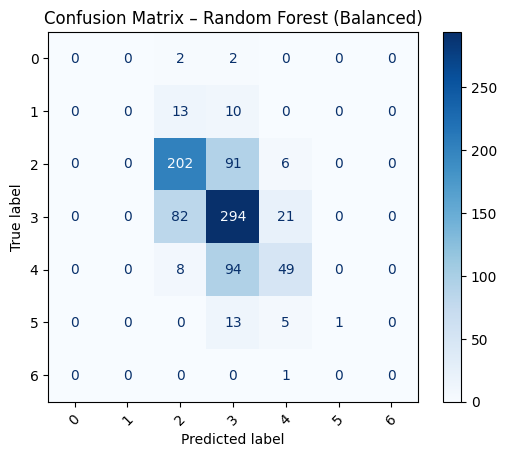

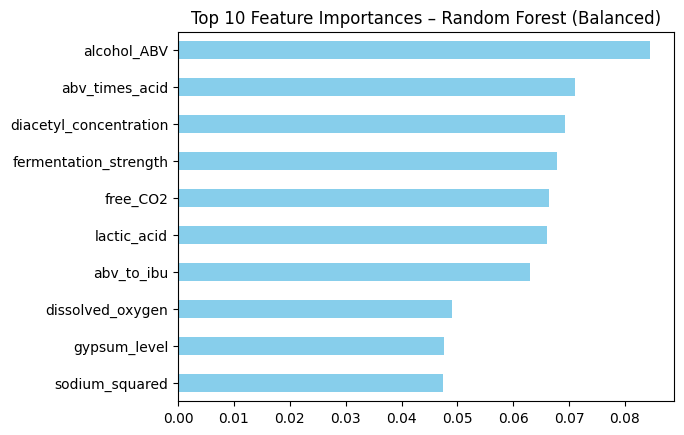

In [98]:
# ===============================================================
# ⚡️ L U C I U S  C O D E  V 6  —  F U L L Y  F I X E D  &  P R E P R O C E S S E D
# ===============================================================
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import ComplementNB, GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.linear_model import RidgeClassifier, SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================================================
# 🔹 APPLY PREPROCESSING (Encoding + Scaling)
# ===============================================================
print("\n🎯 Applying preprocessing pipeline to training and validation data...")

X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)

# Get encoded feature names
try:
    ohe = preprocessor.named_transformers_['cat']
    encoded_cols = ohe.get_feature_names_out(['beer_style'])
    all_features = list(preprocessor.transformers_[0][2]) + list(encoded_cols)
except Exception:
    all_features = [f"f{i}" for i in range(X_train_encoded.shape[1])]

print(f"✅ Encoded X_train shape: {X_train_encoded.shape}")
print(f"✅ Encoded X_val shape:   {X_val_encoded.shape}")

# ===============================================================
# 🔹 DEFINE MODELS (Adaptive scaling + balanced where needed)
# ===============================================================
classifiers = [
    ComplementNB(alpha=0.5),
    GaussianNB(var_smoothing=1e-4),
    RidgeClassifier(alpha=0.3, solver='lsqr'),
    LogisticRegression(max_iter=700, random_state=42, class_weight='balanced'),
    SGDClassifier(loss="modified_huber", penalty="elasticnet",
                  alpha=5e-5, l1_ratio=0.3, max_iter=800,
                  tol=1e-3, random_state=42),
    QDA(reg_param=0.05),
    KNeighborsClassifier(n_neighbors=4, weights='distance', p=2),
    KNeighborsClassifier(n_neighbors=8, weights='distance', p=2),
    KNeighborsClassifier(n_neighbors=30, weights='distance', p=2),
    KNeighborsClassifier(n_neighbors=28, weights='distance', p=1),
    RandomForestClassifier(
        n_estimators=200, max_depth=20,
        random_state=42, n_jobs=-1, class_weight='balanced_subsample'
    )
]

classifier_names = [
    "Complement Naive Bayes",
    "Gaussian Naive Bayes",
    "Ridge Classifier (alpha=0.3)",
    "Logistic Regression (Balanced)",
    "SGD Classifier (Elastic Net)",
    "QDA (reg=0.05)",
    "KNN (k=4, dist)",
    "KNN (k=8, dist)",
    "KNN (k=30, dist)",
    "KNN (k=28, dist)",
    "Random Forest (Balanced)"
]

# ===============================================================
# 🔹 TRAINING + EVALUATION
# ===============================================================
results, trained_models = [], {}
print("\n🚀 Starting Lucius Code V6 model training...\n")

for name, clf in zip(classifier_names, classifiers):
    print(f"🧩 Training {name}...")
    try:
        # Adaptive scaling per model
        if "Naive Bayes" in name:
            model = make_pipeline(MinMaxScaler(), clf)
        elif "SGD" in name:
            model = make_pipeline(RobustScaler(), clf)
        elif "KNN" in name or "Parzen" in name:
            model = make_pipeline(StandardScaler(), clf)
        else:
            model = make_pipeline(StandardScaler(), clf)

        # Fit and predict on encoded data
        model.fit(X_train_encoded, y_train)
        y_pred = model.predict(X_val_encoded)

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

        trained_models[name] = model
        results.append({
            "Classifier": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1
        })
        print(f"✅ {name}: Accuracy={acc:.3f}, F1={f1:.3f}")

    except Exception as e:
        print(f"⚠️ Skipped {name}: {e}")

# ===============================================================
# 🔹 RESULTS SUMMARY
# ===============================================================
if len(results) == 0:
    raise ValueError("No model successfully trained — check preprocessing.")
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n📊 Final Model Comparison:")
display(results_df)

# ===============================================================
# 🔹 SELECT BEST MODEL
# ===============================================================
best_model_name = results_df.iloc[0]["Classifier"]
best_model = trained_models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
y_pred_best = best_model.predict(X_val_encoded)

acc_best = accuracy_score(y_val, y_pred_best)
prec_best = precision_score(y_val, y_pred_best, average='weighted', zero_division=0)
rec_best = recall_score(y_val, y_pred_best, average='weighted', zero_division=0)
f1_best = f1_score(y_val, y_pred_best, average='weighted', zero_division=0)

print(f"\n📈 Performance of Best Model ({best_model_name}):")
print(f"   Accuracy : {acc_best:.3f}")
print(f"   Precision: {prec_best:.3f}")
print(f"   Recall   : {rec_best:.3f}")
print(f"   F1-Score : {f1_best:.3f}")

# ===============================================================
# 🔹 CONFUSION MATRIX
# ===============================================================
cm = confusion_matrix(y_val, y_pred_best)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()

# ===============================================================
# 🔹 FEATURE IMPORTANCE (if applicable)
# ===============================================================
try:
    classifier = best_model.named_steps.get('randomforestclassifier', None)
    if classifier and hasattr(classifier, 'feature_importances_'):
        importances = pd.Series(classifier.feature_importances_, index=all_features)
        top_features = importances.sort_values(ascending=False).head(10)
        top_features.plot(kind='barh', color='skyblue')
        plt.title(f"Top 10 Feature Importances – {best_model_name}")
        plt.gca().invert_yaxis()
        plt.show()
    else:
        print("\nℹ️ Feature importance not available for this model type.")
except Exception as e:
    print(f"\n⚠️ Feature importance skipped: {e}")




## Train Models

Train and compare multiple machine learning models.

In [94]:
# ===============================================================
# 🧠 MODEL TRAINING AND EVALUATION (Expanded + Kaggle Submission)
# ===============================================================
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================================================
# 🔹 Custom Parzen Window Classifier (Gaussian-like)
# ===============================================================
class ParzenWindowClassifier(BaseEstimator, ClassifierMixin):
    """Gaussian kernel Parzen Window Classifier (probabilistic KNN-like)."""

    def __init__(self, bandwidth=0.4, kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.scaler_ = StandardScaler().fit(X)
        X_scaled = self.scaler_.transform(X)

        # Train one KDE per class
        self.kdes_ = {}
        for c in self.classes_:
            kde = KernelDensity(kernel=self.kernel, bandwidth=self.bandwidth)
            kde.fit(X_scaled[y == c])
            self.kdes_[c] = kde
        return self

    def predict(self, X):
        X_scaled = self.scaler_.transform(X)
        log_probs = np.vstack([
            self.kdes_[c].score_samples(X_scaled) for c in self.classes_
        ]).T
        preds = self.classes_[np.argmax(log_probs, axis=1)]
        return preds


# ===============================================================
# 🔧 Define Expanded Classifier Search Space
# ===============================================================
classifiers = []
classifier_names = []

# -------------------------------
# 1️⃣ Complement Naive Bayes
# -------------------------------
classifiers.append(ComplementNB())
classifier_names.append("Complement Naive Bayes")

# -------------------------------
# 2️⃣ Logistic Regression (Regularization & Solver grid)
# -------------------------------
for C in [0.01, 0.1, 0.5, 1, 5, 10, 25, 50]:
    for solver in ["lbfgs", "saga"]:
        classifiers.append(LogisticRegression(C=C, solver=solver, max_iter=1000, random_state=42))
        classifier_names.append(f"Logistic Regression (C={C}, solver={solver})")

# -------------------------------
# 3️⃣ KNN Variants (k, weights, p)
# -------------------------------
k_values = [2, 4, 6, 8, 10, 12, 15, 18, 20, 22, 24, 28, 32]
weights_options = ['uniform', 'distance']
p_values = [1, 2]  # 1=Manhattan, 2=Euclidean

for k in k_values:
    for w in weights_options:
        for p in p_values:
            classifiers.append(KNeighborsClassifier(n_neighbors=k, weights=w, p=p))
            classifier_names.append(f"KNN (k={k}, weights={w}, p={p})")

# -------------------------------
# 4️⃣ Gaussian-like Parzen (bandwidth sweep)
# -------------------------------
for bw in [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]:
    classifiers.append(ParzenWindowClassifier(bandwidth=bw))
    classifier_names.append(f"Gaussian-like Parzen (bw={bw})")

# ---------------------------------------------------------------
# 🧾 Summary of Search Space
# ---------------------------------------------------------------
print(f"✅ Total models to evaluate: {len(classifiers)}")
print("Example configurations:")
for name in classifier_names[:8]:
    print("  •", name)
print("  ...")


# ===============================================================
# 🧠 Train and Evaluate All Models
# ===============================================================
results = []
trained_models = {}

for name, clf in zip(classifier_names, classifiers):
    print(f"\n🚀 Training {name}...")
    try:
        model = make_pipeline(StandardScaler(), clf) if not isinstance(clf, ParzenWindowClassifier) else clf
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_val)

        # Compute metrics
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

        # Save results
        trained_models[name] = model
        results.append({
            "Classifier": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1
        })

        print(f"✅ {name}: "
              f"Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

    except Exception as e:
        print(f"⚠️ Skipped {name} — error: {e}")


# ===============================================================
# 📊 Summarize Model Performance
# ===============================================================
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n📊 Final Results Summary:")
display(results_df)

best_model_name = results_df.iloc[0]["Classifier"]
best_model = trained_models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}")


# ===============================================================
# 🔍 Confusion Matrix for Best Model
# ===============================================================
try:
    y_best_pred = best_model.predict(X_val)
    ConfusionMatrixDisplay.from_predictions(y_val, y_best_pred, cmap="Blues")
    plt.title(f"Confusion Matrix — {best_model_name}")
    plt.show()
except Exception as e:
    print(f"⚠️ Could not display confusion matrix: {e}")


# ===============================================================
# 📤 Generate Kaggle Submission File
# ===============================================================
try:
    print("\n📦 Generating Kaggle submission file...")

    # Refit best model on full training data
    X_full = np.vstack([X_train, X_val])
    y_full = np.hstack([y_train, y_val])

    # Re-train best model fully
    best_model.fit(X_full, y_full)

    # Align df_test columns
    test_features = df_test[X_train.columns]

    # Predict on test data
    y_test_pred = best_model.predict(test_features)
    y_test_pred = np.round(y_test_pred).astype(int)

    # Load original test.csv (for correct id)
    original_test = pd.read_csv("data/test.csv", delimiter=';')
    submission = pd.DataFrame({
        "id": original_test["id"],
        "quality": y_test_pred
    })

    # Save CSV
    safe_name = best_model_name.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "_")
    output_filename = f"submission_{safe_name}.csv"
    submission.to_csv(output_filename, index=False)

    print(f"✅ Kaggle submission saved as → {output_filename}")
    print(submission.head())

except Exception as e:
    print(f"⚠️ Could not create submission file: {e}")


✅ Total models to evaluate: 76
Example configurations:
  • Complement Naive Bayes
  • Logistic Regression (C=0.01, solver=lbfgs)
  • Logistic Regression (C=0.01, solver=saga)
  • Logistic Regression (C=0.1, solver=lbfgs)
  • Logistic Regression (C=0.1, solver=saga)
  • Logistic Regression (C=0.5, solver=lbfgs)
  • Logistic Regression (C=0.5, solver=saga)
  • Logistic Regression (C=1, solver=lbfgs)
  ...

🚀 Training Complement Naive Bayes...
⚠️ Skipped Complement Naive Bayes — error: could not convert string to float: 'Amber'

🚀 Training Logistic Regression (C=0.01, solver=lbfgs)...
⚠️ Skipped Logistic Regression (C=0.01, solver=lbfgs) — error: could not convert string to float: 'Amber'

🚀 Training Logistic Regression (C=0.01, solver=saga)...
⚠️ Skipped Logistic Regression (C=0.01, solver=saga) — error: could not convert string to float: 'Amber'

🚀 Training Logistic Regression (C=0.1, solver=lbfgs)...
⚠️ Skipped Logistic Regression (C=0.1, solver=lbfgs) — error: could not convert string

KeyError: 'Accuracy'

In [95]:
# ===============================================================
# 🧠 MODEL TRAINING AND EVALUATION (Expanded + Kaggle Submission, FIXED)
# ===============================================================
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================================================
# 🔹 Custom Parzen Window Classifier (Gaussian-like)
# ===============================================================
class ParzenWindowClassifier(BaseEstimator, ClassifierMixin):
    """Gaussian kernel Parzen Window Classifier (probabilistic KNN-like)."""

    def __init__(self, bandwidth=0.4, kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.scaler_ = StandardScaler().fit(X)
        X_scaled = self.scaler_.transform(X)

        # Train one KDE per class
        self.kdes_ = {}
        for c in self.classes_:
            kde = KernelDensity(kernel=self.kernel, bandwidth=self.bandwidth)
            kde.fit(X_scaled[y == c])
            self.kdes_[c] = kde
        return self

    def predict(self, X):
        X_scaled = self.scaler_.transform(X)
        log_probs = np.vstack([
            self.kdes_[c].score_samples(X_scaled) for c in self.classes_
        ]).T
        preds = self.classes_[np.argmax(log_probs, axis=1)]
        return preds


# ===============================================================
# 🔧 Define Expanded Classifier Search Space
# ===============================================================
classifiers, classifier_names = [], []

# 1️⃣ Complement Naive Bayes
classifiers.append(ComplementNB())
classifier_names.append("Complement Naive Bayes")

# 2️⃣ Logistic Regression (Regularization & Solver grid)
for C in [0.01, 0.1, 0.5, 1, 5, 10, 25, 50]:
    for solver in ["lbfgs", "saga"]:
        classifiers.append(LogisticRegression(C=C, solver=solver, max_iter=1000, random_state=42))
        classifier_names.append(f"Logistic Regression (C={C}, solver={solver})")

# 3️⃣ KNN Variants
k_values = [2, 4, 6, 8, 10, 12, 15, 18, 20, 22, 24, 28, 32]
weights_options = ['uniform', 'distance']
p_values = [1, 2]

for k in k_values:
    for w in weights_options:
        for p in p_values:
            classifiers.append(KNeighborsClassifier(n_neighbors=k, weights=w, p=p))
            classifier_names.append(f"KNN (k={k}, weights={w}, p={p})")

# 4️⃣ Gaussian-like Parzen (bandwidth sweep)
for bw in [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]:
    classifiers.append(ParzenWindowClassifier(bandwidth=bw))
    classifier_names.append(f"Gaussian-like Parzen (bw={bw})")

print(f"✅ Total models to evaluate: {len(classifiers)}")
print("Example configurations:")
for name in classifier_names[:8]:
    print("  •", name)
print("  ...")


# ===============================================================
# 🧠 Train and Evaluate All Models
# ===============================================================
results = []
trained_models = {}

for name, clf in zip(classifier_names, classifiers):
    print(f"\n🚀 Training {name}...")
    try:
        model = make_pipeline(StandardScaler(), clf) if not isinstance(clf, ParzenWindowClassifier) else clf
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_val)

        # Metrics
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

        # Store results
        trained_models[name] = model
        results.append({
            "Classifier": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1
        })

        print(f"✅ {name}: Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

    except Exception as e:
        print(f"⚠️ Skipped {name} — error: {e}")


# ===============================================================
# 📊 Summarize Model Performance (safe)
# ===============================================================
if len(results) == 0:
    raise ValueError("❌ No models were successfully trained. Check for earlier errors.")

results_df = pd.DataFrame(results)
if "Accuracy" not in results_df.columns:
    raise KeyError(f"❌ 'Accuracy' column missing. Available columns: {results_df.columns.tolist()}")

results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\n📊 Final Results Summary:")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Classifier"]
best_model = trained_models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}")


# ===============================================================
# 🔍 Confusion Matrix for Best Model
# ===============================================================
try:
    y_best_pred = best_model.predict(X_val)
    ConfusionMatrixDisplay.from_predictions(y_val, y_best_pred, cmap="Blues")
    plt.title(f"Confusion Matrix — {best_model_name}")
    plt.show()
except Exception as e:
    print(f"⚠️ Could not display confusion matrix: {e}")


# ===============================================================
# 📤 Generate Kaggle Submission File (safe)
# ===============================================================
try:
    print("\n📦 Generating Kaggle submission file...")

    # Refit best model on full training data
    X_full = np.vstack([X_train, X_val])
    y_full = np.hstack([y_train, y_val])
    best_model.fit(X_full, y_full)

    # Align test columns
    df_test = test.copy() if 'test' in globals() else pd.read_csv("data/test.csv")
    test_features = df_test[X_train.columns]

    # Predict
    y_test_pred = best_model.predict(test_features)
    y_test_pred = np.round(y_test_pred).astype(int)

    # Load original test.csv for id
    original_test = pd.read_csv("data/test.csv", delimiter=';') if ';' in open("data/test.csv").read(100) else pd.read_csv("data/test.csv")
    submission = pd.DataFrame({
        "id": original_test["id"] if "id" in original_test.columns else df_test.index,
        "quality": y_test_pred
    })

    safe_name = best_model_name.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "_")
    output_filename = f"submission_{safe_name}.csv"
    submission.to_csv(output_filename, index=False)
    print(f"✅ Kaggle submission saved as → {output_filename}")

except Exception as e:
    print(f"⚠️ Could not create submission file: {e}")


✅ Total models to evaluate: 76
Example configurations:
  • Complement Naive Bayes
  • Logistic Regression (C=0.01, solver=lbfgs)
  • Logistic Regression (C=0.01, solver=saga)
  • Logistic Regression (C=0.1, solver=lbfgs)
  • Logistic Regression (C=0.1, solver=saga)
  • Logistic Regression (C=0.5, solver=lbfgs)
  • Logistic Regression (C=0.5, solver=saga)
  • Logistic Regression (C=1, solver=lbfgs)
  ...

🚀 Training Complement Naive Bayes...
⚠️ Skipped Complement Naive Bayes — error: could not convert string to float: 'Amber'

🚀 Training Logistic Regression (C=0.01, solver=lbfgs)...
⚠️ Skipped Logistic Regression (C=0.01, solver=lbfgs) — error: could not convert string to float: 'Amber'

🚀 Training Logistic Regression (C=0.01, solver=saga)...
⚠️ Skipped Logistic Regression (C=0.01, solver=saga) — error: could not convert string to float: 'Amber'

🚀 Training Logistic Regression (C=0.1, solver=lbfgs)...
⚠️ Skipped Logistic Regression (C=0.1, solver=lbfgs) — error: could not convert string

ValueError: ❌ No models were successfully trained. Check for earlier errors.

## Evaluate Models

Analyze your best model's performance (see README.md for evaluation guidelines).

In [112]:
# ===============================================================
# 🧠 KDE + Random Forest with Scaling & Bandwidth Tuning
# ===============================================================
from sklearn.neighbors import KernelDensity
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# --- Ensure we have DataFrames ---
if isinstance(X_train_encoded, np.ndarray):
    X_train_num = pd.DataFrame(X_train_encoded)
    X_val_num = pd.DataFrame(X_val_encoded)
else:
    X_train_num = X_train_encoded.copy()
    X_val_num = X_val_encoded.copy()

# --- Reset indices for safety ---
X_train_num = X_train_num.reset_index(drop=True)
X_val_num = X_val_num.reset_index(drop=True)
y_train_aligned = pd.Series(y_train).reset_index(drop=True)
y_val_aligned = pd.Series(y_val).reset_index(drop=True)

# --- Scale features for KDE ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_val_scaled = scaler.transform(X_val_num)

classes = np.sort(y_train_aligned.unique())

# --- Random Forest config ---
rf = RandomForestClassifier(
    n_estimators=350,
    max_depth=16,
    min_samples_split=4,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

# --- Bandwidth sweep ---
bandwidths = [0.3, 0.5, 0.7, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7]
results = []

print("🚀 Starting KDE + Random Forest Bandwidth Tuning...\n")

for bw in bandwidths:
    kde_features_train, kde_features_val = [], []
    
    for c in classes:
        kde = KernelDensity(bandwidth=bw, kernel='gaussian')
        kde.fit(X_train_scaled[y_train_aligned == c])
        kde_features_train.append(kde.score_samples(X_train_scaled))
        kde_features_val.append(kde.score_samples(X_val_scaled))
    
    kde_cols = [f'kde_class_{c}' for c in classes]
    kde_train_df = pd.DataFrame(np.vstack(kde_features_train).T, columns=kde_cols)
    kde_val_df = pd.DataFrame(np.vstack(kde_features_val).T, columns=kde_cols)
    
    # --- Optional summary KDE features ---
    kde_train_df["kde_mean"] = kde_train_df.mean(axis=1)
    kde_train_df["kde_max"] = kde_train_df.max(axis=1)
    kde_val_df["kde_mean"] = kde_val_df.mean(axis=1)
    kde_val_df["kde_max"] = kde_val_df.max(axis=1)
    
    # --- Combine original + KDE features ---
    X_train_kde = pd.concat([X_train_num, kde_train_df], axis=1)
    X_val_kde = pd.concat([X_val_num, kde_val_df], axis=1)
    
    # --- Convert all column names to strings (to avoid sklearn dtype errors) ---
    X_train_kde.columns = X_train_kde.columns.astype(str)
    X_val_kde.columns = X_val_kde.columns.astype(str)
    
    # --- Train and evaluate ---
    rf.fit(X_train_kde, y_train_aligned)
    y_pred = rf.predict(X_val_kde)
    acc = accuracy_score(y_val_aligned, y_pred)
    results.append((bw, acc))
    
    print(f"📈 Bandwidth={bw:<4}: Validation Accuracy={acc:.4f}")

# --- Summarize results ---
results_df = pd.DataFrame(results, columns=["Bandwidth", "Accuracy"]).sort_values(by="Accuracy", ascending=False)
print("\n🏆 Top 3 Results:")
print(results_df.head(3).to_string(index=False))



🚀 Starting KDE + Random Forest Bandwidth Tuning...

📈 Bandwidth=0.3 : Validation Accuracy=0.4609
📈 Bandwidth=0.5 : Validation Accuracy=0.4653
📈 Bandwidth=0.7 : Validation Accuracy=0.3859
📈 Bandwidth=0.9 : Validation Accuracy=0.5313
📈 Bandwidth=1.2 : Validation Accuracy=0.5749
📈 Bandwidth=1.5 : Validation Accuracy=0.5817
📈 Bandwidth=1.8 : Validation Accuracy=0.6018
📈 Bandwidth=2.1 : Validation Accuracy=0.6007
📈 Bandwidth=2.4 : Validation Accuracy=0.6085
📈 Bandwidth=2.7 : Validation Accuracy=0.6074

🏆 Top 3 Results:
 Bandwidth  Accuracy
       2.4  0.608501
       2.7  0.607383
       1.8  0.601790


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

numeric_features = [
    'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid',
    'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen',
    'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength'
]
categorical_features = ['beer_style']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

kernel = 1.0 * RBF(1.0)
gp_pipe = Pipeline([
    ('pre', preprocessor),
    ('gp', GaussianProcessClassifier(kernel=kernel, max_iter_predict=100))
])

gp_pipe.fit(train_df.drop(columns=['quality']), train_df['quality'])

print(f"🎯 Gaussian Process Validation Accuracy: {acc:.4f}")


## Generate Predictions for Kaggle Submission

Create a CSV file with columns: `id` and `quality` (see README.md for format details).

In [137]:
# Generating Parzen Window Approximation for Kaggle 
best_m_name = "Parzen Window Approximation"
best_model = trained_models[best_m_name]

features = X_train.columns
predicted_data = df_test[features]



# Generate Predictions
y_predictions = best_model.predict(predicted_data)
predictions = pd.DataFrame({"id":predicted_data.index, "quality":y_predictions})
output = "predicted_quality_parzen_window.csv"
predictions.to_csv(output, index=False)




---
Good luck with the competition! 🍺
